# Vesper Capital — 1-Hour Model

Parallel experiment to the validated 24-hour walk-forward model.

**Key differences from 24h model:**
- Target is 1-hour forward return instead of 24-hour
- Wallet features shifted back 1 hour (D21 causal ordering requirement)
- Threshold search over smaller range (1h returns are ~24x smaller)
- Capital simulation is simpler — no overlapping positions, no cooldown
  needed. Long when signal fires, flat otherwise. Cost on transitions only.

**What to look for:**
1. Is the 1h edge statistically significant? (may be weaker per F8)
2. Does the mean 1h edge clear the 0.2% round-trip cost hurdle?
3. If not, can the 1h model serve as a signal filter for the 24h model?

*Design decision D21: wallet features shifted 1h back to prevent*
*reactive-behavior leakage into the 1h target window.*

## 1. Configuration

In [1]:
from claude_refactor_core_utils import *
from dateutil.relativedelta import relativedelta
from datetime import date, timedelta
import pandas as pd
import numpy as np
import os
import calendar
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Window boundaries ──────────────────────────────────────────
FULL_START        = date(2023, 1, 1)
FULL_END          = date(2024, 12, 31)
TARGET_HORIZON_H  = 1      # 1-hour target — cleaner capital sim
MIN_DELTA_ETH     = 0.005
ROLLING_WINDOWS   = [6, 24, 72, 168]

# ── Capital simulation ─────────────────────────────────────────
INITIAL_CAPITAL   = 100_000
POSITION_PCT      = 0.25
TRANSACTION_COST  = 0.001   # 0.1% per side
MAX_POSITION_PCT  = 0.50
MIN_MEANINGFUL_THRESHOLD = 0.05  # lower floor — 1h model may select smaller thresholds

# ── Walk-forward config ────────────────────────────────────────
TRAIN_MONTHS      = 4
VAL_MONTHS        = 2
THRESHOLD_SEARCH  = np.arange(0.0, 0.5, 0.01)  # 1h returns are small — tighter range
MIN_VAL_ACTIVE    = 10

# ── Model params ───────────────────────────────────────────────
MODEL_PARAMS = dict(
    n_estimators=200, max_depth=3, learning_rate=0.02,
    subsample=0.6, colsample_bytree=0.3, min_child_weight=50,
    reg_alpha=1.0, reg_lambda=5.0, random_state=42,
    n_jobs=-1, verbosity=0
)

# ── Files ──────────────────────────────────────────────────────
HOURLY_BALANCE_CSV = '/home/colin/projects/blockchain_alpha/data/balance_store_hourly_top200.csv'
DAILY_SKILL_CSV    = '/home/colin/projects/blockchain_alpha/data/random_10k_skill_results.csv'
WF_1H_RESULTS_CSV  = '/home/colin/projects/blockchain_alpha/data/walkforward_1h_results.csv'

print(f"Window: {FULL_START} to {FULL_END}")
print(f"Target horizon: {TARGET_HORIZON_H} hour")
print(f"Initial capital: ${INITIAL_CAPITAL:,.0f}")
print(f"Threshold search: {THRESHOLD_SEARCH[0]:.2f} to {THRESHOLD_SEARCH[-1]:.2f}")


Window: 2023-01-01 to 2024-12-31
Target horizon: 1 hour
Initial capital: $100,000
Threshold search: 0.00 to 0.49


## 2. Load data

In [2]:
print("Loading hourly balance store...")
raw = pd.read_csv(HOURLY_BALANCE_CSV)
raw['date']        = pd.to_datetime(raw['date'], format='mixed').dt.floor('h')
raw['address']     = raw['address'].str.lower().str.strip()
raw['balance_wei'] = pd.to_numeric(raw['balance_wei'], errors='coerce').fillna(0).astype('int64')

hourly = (
    raw.sort_values(['address','date','block_number'])
    .groupby(['address','date'], as_index=False).tail(1)
    .reset_index(drop=True)
)
hourly['balance_eth'] = hourly['balance_wei'] / 1e18
hourly = hourly.sort_values(['address','date'])
hourly['delta_eth'] = hourly.groupby('address')['balance_eth'].diff()
hourly['action_raw'] = hourly['delta_eth'].apply(
    lambda d: 1 if d > MIN_DELTA_ETH else (-1 if d < -MIN_DELTA_ETH else 0)
)
wallet_list = sorted(hourly['address'].unique().tolist())

print("Loading hourly prices...")
df_price = load_eth_usd_cryptocompare(
    start=str(FULL_START), end=str(FULL_END), interval='1h'
)
df_price['date'] = pd.to_datetime(df_price['date']).dt.floor('h')
df_price = df_price.sort_values('date').reset_index(drop=True)

# 1-hour forward return target
df_price['fwd_return'] = (
    df_price['close'].shift(-TARGET_HORIZON_H) - df_price['close']
) / df_price['close'] * 100

# Price context features
df_price['ret_1h']      = df_price['close'].pct_change(1)  * 100
df_price['ret_4h']      = df_price['close'].pct_change(4)  * 100
df_price['ret_24h']     = df_price['close'].pct_change(24) * 100
df_price['ret_72h']     = df_price['close'].pct_change(72) * 100
df_price['vol_24h']     = df_price['ret_1h'].rolling(24).std()
df_price['vol_72h']     = df_price['ret_1h'].rolling(72).std()
df_price['hour_of_day'] = df_price['date'].dt.hour
df_price['day_of_week'] = df_price['date'].dt.dayofweek

print(f"Wallets: {len(wallet_list)}, Hours: {len(df_price):,}")
print(f"Target: {TARGET_HORIZON_H}h forward return")
print(f"  Mean fwd_return: {df_price['fwd_return'].mean():.6f}%")
print(f"  Std  fwd_return: {df_price['fwd_return'].std():.4f}%")


Loading hourly balance store...
Loading hourly prices...
Wallets: 201, Hours: 17,521
Target: 1h forward return
  Mean fwd_return: 0.007623%
  Std  fwd_return: 0.5959%


## 3. Build feature matrix with 1-hour causal shift

Per D21: all wallet action features are shifted back 1 hour before training. Feature at row t reflects wallet actions from hour t-1, guaranteeing the wallet action precedes the 1h target window.

In [3]:
print("Building feature matrix with 1-hour causal shift (D21)...")

action_wide = hourly.pivot_table(
    index='date', columns='address', values='action_raw', aggfunc='first'
).fillna(0)
delta_wide = hourly.pivot_table(
    index='date', columns='address', values='delta_eth', aggfunc='first'
).fillna(0)

wallet_features = pd.DataFrame(index=action_wide.index)
for addr in wallet_list:
    if addr not in action_wide.columns:
        continue
    short = addr[:10]
    act   = action_wide[addr]
    dlt   = delta_wide[addr]
    wallet_features[f'{short}_action']     = act
    wallet_features[f'{short}_wtd_action'] = dlt * act.abs()
    for w in ROLLING_WINDOWS:
        wallet_features[f'{short}_buy_pressure_{w}h'] = (
            (act > 0).astype(float).rolling(w, min_periods=1).mean()
        )
    wallet_features[f'{short}_max_buy_24h'] = dlt.clip(lower=0).rolling(24, min_periods=1).max()

buy_matrix  = (action_wide > 0).astype(float)
sell_matrix = (action_wide < 0).astype(float)
wallet_features['pool_buy_fraction']  = buy_matrix.mean(axis=1)
wallet_features['pool_sell_fraction'] = sell_matrix.mean(axis=1)
wallet_features['pool_net_fraction']  = (
    wallet_features['pool_buy_fraction'] - wallet_features['pool_sell_fraction']
)
buy_pressure  = delta_wide.clip(lower=0).sum(axis=1)
sell_pressure = delta_wide.clip(upper=0).abs().sum(axis=1)
total_vol     = buy_pressure + sell_pressure + 1e-9
wallet_features['pool_net_pressure_eth'] = (buy_pressure - sell_pressure) / total_vol
for w in [6, 24, 72]:
    wallet_features[f'pool_buy_fraction_{w}h'] = (
        wallet_features['pool_buy_fraction'].rolling(w, min_periods=1).mean()
    )
    wallet_features[f'pool_net_pressure_{w}h'] = (
        wallet_features['pool_net_pressure_eth'].rolling(w, min_periods=1).mean()
    )
n_active = (action_wide != 0).sum(axis=1).clip(lower=1)
n_agree  = buy_matrix.sum(axis=1).combine(sell_matrix.sum(axis=1), max)
wallet_features['pool_conviction'] = n_agree / n_active

# ── D21: Shift wallet features back 1 hour ─────────────────────
# For 1h target: feature at row t must use wallet actions from t-1
# This guarantees the wallet action precedes the entire target window
# Without this shift, a wallet reacting to intra-hour price movement
# at hour t could spuriously appear to predict the 1h return
print("  Applying 1-hour causal shift to wallet features (D21)...")
wallet_cols = [c for c in wallet_features.columns]
wallet_features[wallet_cols] = wallet_features[wallet_cols].shift(1)

feature_df = wallet_features.reset_index().rename(columns={'date':'timestamp'})
price_cols  = ['date','close','fwd_return',
               'ret_1h','ret_4h','ret_24h','ret_72h',
               'vol_24h','vol_72h','hour_of_day','day_of_week']
full_df = feature_df.merge(
    df_price[price_cols].rename(columns={'date':'timestamp'}),
    on='timestamp', how='inner'
).dropna(subset=['fwd_return']).dropna().reset_index(drop=True)

EXCLUDE_COLS = ['timestamp','close','fwd_return']
FEATURE_COLS = [c for c in full_df.columns if c not in EXCLUDE_COLS]
print(f"Feature matrix: {full_df.shape}, Features: {len(FEATURE_COLS)}")
print(f"Note: wallet features shifted 1h back per D21 causal ordering requirement")


Building feature matrix with 1-hour causal shift (D21)...
  Applying 1-hour causal shift to wallet features (D21)...
Feature matrix: (17448, 1429), Features: 1426
Note: wallet features shifted 1h back per D21 causal ordering requirement


## 4. Walk-forward fold schedule

In [4]:
folds = []
cursor = FULL_START

while True:
    train_start = cursor
    train_end_month = train_start.month + TRAIN_MONTHS + VAL_MONTHS - 1
    train_end = date(
        train_start.year + (train_end_month - 1) // 12,
        (train_end_month - 1) % 12 + 1,
        calendar.monthrange(
            train_start.year + (train_end_month - 1) // 12,
            (train_end_month - 1) % 12 + 1
        )[1]
    )
    test_start = train_end + timedelta(days=1)
    test_end   = date(
        test_start.year + (test_start.month - 1) // 12,
        test_start.month,
        calendar.monthrange(test_start.year, test_start.month)[1]
    )
    if test_end > FULL_END:
        break
    folds.append({
        'train_start': train_start, 'train_end': train_end,
        'test_start':  test_start,  'test_end':  test_end,
    })
    next_month = cursor.month + 1
    next_year  = cursor.year + (next_month - 1) // 12
    next_month = (next_month - 1) % 12 + 1
    cursor = date(next_year, next_month, 1)

print(f"Walk-forward folds: {len(folds)}")
for i, f in enumerate(folds):
    print(f"  Fold {i+1:2d}: train {f['train_start']} to {f['train_end']}  "
          f"test {f['test_start']} to {f['test_end']}")


Walk-forward folds: 18
  Fold  1: train 2023-01-01 to 2023-06-30  test 2023-07-01 to 2023-07-31
  Fold  2: train 2023-02-01 to 2023-07-31  test 2023-08-01 to 2023-08-31
  Fold  3: train 2023-03-01 to 2023-08-31  test 2023-09-01 to 2023-09-30
  Fold  4: train 2023-04-01 to 2023-09-30  test 2023-10-01 to 2023-10-31
  Fold  5: train 2023-05-01 to 2023-10-31  test 2023-11-01 to 2023-11-30
  Fold  6: train 2023-06-01 to 2023-11-30  test 2023-12-01 to 2023-12-31
  Fold  7: train 2023-07-01 to 2023-12-31  test 2024-01-01 to 2024-01-31
  Fold  8: train 2023-08-01 to 2024-01-31  test 2024-02-01 to 2024-02-29
  Fold  9: train 2023-09-01 to 2024-02-29  test 2024-03-01 to 2024-03-31
  Fold 10: train 2023-10-01 to 2024-03-31  test 2024-04-01 to 2024-04-30
  Fold 11: train 2023-11-01 to 2024-04-30  test 2024-05-01 to 2024-05-31
  Fold 12: train 2023-12-01 to 2024-05-31  test 2024-06-01 to 2024-06-30
  Fold 13: train 2024-01-01 to 2024-06-30  test 2024-07-01 to 2024-07-31
  Fold 14: train 2024-02-01 

## 5. Walk-forward validation — 1h target

In [5]:
from scipy import stats as scipy_stats

def run_walkforward_1h(full_df, folds, feature_cols,
                       model_params, threshold_search, min_val_active):
    """
    Walk-forward for 1-hour target model.
    Same architecture as 24h model but:
    - Target is 1h forward return (already in fwd_return column)
    - Wallet features already shifted 1h back (D21)
    - Threshold search over smaller range (1h returns are ~10x smaller)
    """
    results = []

    for fold_idx, fold in enumerate(folds):
        val_start        = fold['train_end'] - relativedelta(months=2) + relativedelta(days=1)
        train_end_actual = val_start - relativedelta(days=1)

        train_mask = ((full_df['timestamp'].dt.date >= fold['train_start']) &
                      (full_df['timestamp'].dt.date <= train_end_actual))
        val_mask   = ((full_df['timestamp'].dt.date >= val_start) &
                      (full_df['timestamp'].dt.date <= fold['train_end']))
        test_mask  = ((full_df['timestamp'].dt.date >= fold['test_start']) &
                      (full_df['timestamp'].dt.date <= fold['test_end']))

        train_fold = full_df[train_mask].copy()
        val_fold   = full_df[val_mask].copy()
        test_fold  = full_df[test_mask].copy()

        if len(train_fold) < 200 or len(val_fold) < 100 or len(test_fold) < 50:
            continue

        X_train = train_fold[feature_cols].values
        y_train = train_fold['fwd_return'].values
        X_val   = val_fold[feature_cols].values
        y_val   = val_fold['fwd_return'].values
        X_test  = test_fold[feature_cols].values
        y_test  = test_fold['fwd_return'].values

        model_fold = xgb.XGBRegressor(**model_params)
        model_fold.fit(X_train, y_train)

        y_pred_val  = model_fold.predict(X_val)
        y_pred_test = model_fold.predict(X_test)

        # Threshold selection on validation fold only
        best_threshold = 0.0
        best_val_edge  = -999
        base_val_mean  = y_val.mean()

        for threshold in threshold_search:
            pos   = (y_pred_val > threshold).astype(float)
            n_act = int(pos.sum())
            if n_act < min_val_active:
                continue
            active = pd.Series(pos * y_val)[pos > 0]
            edge   = active.mean() - base_val_mean
            if edge > best_val_edge:
                best_val_edge  = edge
                best_threshold = threshold

        # Test fold evaluation
        test_pos  = (y_pred_test > best_threshold).astype(float)
        active_t  = y_test[test_pos > 0]
        base_mean = y_test.mean()
        edge_t    = active_t.mean() - base_mean if len(active_t) > 0 else 0
        win_rate  = (active_t > 0).mean() if len(active_t) > 0 else 0

        val_max  = y_pred_val.max()
        test_max = y_pred_test.max()

        print(f"Fold {fold_idx+1:2d}: "
              f"test {fold['test_start']} to {fold['test_end']}  "
              f"thr={best_threshold:.3f}  "
              f"n={len(active_t):4d}  "
              f"edge={edge_t:+.5f}%  "
              f"win={win_rate:.3f}  "
              f"val_max={val_max:.4f}/test_max={test_max:.4f}")

        results.append({
            'fold':          fold_idx + 1,
            'test_month':    fold['test_start'].strftime('%Y-%m'),
            'test_start':    fold['test_start'],
            'test_end':      fold['test_end'],
            'threshold':     best_threshold,
            'val_edge':      best_val_edge,
            'val_pred_max':  val_max,
            'test_pred_max': test_max,
            'timestamps':    test_fold['timestamp'].values,
            'actual_returns':test_fold['fwd_return'].values,   # 1h returns
            'close':         test_fold['close'].values,
            'ret_1h':        test_fold['ret_1h'].values,       # actual 1h price change
            'y_pred':        y_pred_test,
            'positions':     test_pos,
        })

    return results

print("Running 1-hour walk-forward validation...")
long_results_1h = run_walkforward_1h(
    full_df, folds, FEATURE_COLS,
    MODEL_PARAMS, THRESHOLD_SEARCH, MIN_VAL_ACTIVE
)
print(f"\n{len(long_results_1h)} folds completed.")


Running 1-hour walk-forward validation...
Fold  1: test 2023-07-01 to 2023-07-31  thr=0.070  n=   4  edge=-0.12808%  win=0.000  val_max=0.1478/test_max=0.1048
Fold  2: test 2023-08-01 to 2023-08-31  thr=0.030  n=  10  edge=+0.07095%  win=0.600  val_max=0.1261/test_max=0.0976
Fold  3: test 2023-09-01 to 2023-09-30  thr=0.080  n=  29  edge=+0.07291%  win=0.621  val_max=0.1751/test_max=0.1713
Fold  4: test 2023-10-01 to 2023-10-31  thr=0.090  n=   6  edge=+0.25330%  win=0.667  val_max=0.1264/test_max=0.1184
Fold  5: test 2023-11-01 to 2023-11-30  thr=0.120  n=   5  edge=+0.24500%  win=0.600  val_max=0.1503/test_max=0.1836
Fold  6: test 2023-12-01 to 2023-12-31  thr=0.120  n=   8  edge=-0.06542%  win=0.375  val_max=0.1627/test_max=0.1569
Fold  7: test 2024-01-01 to 2024-01-31  thr=0.090  n=  51  edge=-0.17711%  win=0.471  val_max=0.1599/test_max=0.1653
Fold  8: test 2024-02-01 to 2024-02-29  thr=0.060  n=  21  edge=+0.05914%  win=0.714  val_max=0.2031/test_max=0.1511
Fold  9: test 2024-03-

## 6. Results analysis & comparison to 24h model

In [6]:
# ── Walk-forward results analysis ─────────────────────────────
rows = []
for r in long_results_1h:
    actual  = r['actual_returns']
    pos     = r['positions']
    active  = actual[pos > 0]
    base    = actual.mean()
    rows.append({
        'test_month':  r['test_month'],
        'threshold':   r['threshold'],
        'n_active':    len(active),
        'edge':        active.mean() - base if len(active) > 0 else 0.0,
        'win_rate':    (active > 0).mean() if len(active) > 0 else 0.0,
        'mean_ret':    active.mean() if len(active) > 0 else 0.0,
        'base_mean':   base,
        'is_november': r['test_start'].month == 11,
        'threshold_ok':r['threshold'] >= MIN_MEANINGFUL_THRESHOLD,
    })

results_df = pd.DataFrame(rows)
results_df.to_csv(WF_1H_RESULTS_CSV, index=False)

print("=" * 65)
print("WALK-FORWARD RESULTS — 1-HOUR MODEL")
print("=" * 65)
print(results_df[['test_month','threshold','n_active','edge',
                   'win_rate','is_november','threshold_ok'
                   ]].to_string(index=False))
print()

active_df   = results_df[results_df['n_active'] >= 5]
non_nov_df  = active_df[~active_df['is_november']]
filtered_df = active_df[active_df['threshold_ok']]
filtered_non_nov = filtered_df[~filtered_df['is_november']]

print(f"Total folds:          {len(results_df)}")
print(f"Active (n >= 5):      {len(active_df)}")
print(f"Above threshold floor:{len(filtered_df)} (threshold >= {MIN_MEANINGFUL_THRESHOLD})")
print()

if len(non_nov_df) > 0:
    import numpy as np
    edges    = non_nov_df['edge'].values
    weights  = non_nov_df['n_active'].values
    print(f"Non-November (all active):")
    print(f"  Unweighted mean edge: {np.mean(edges):+.6f}%/hr")
    print(f"  Weighted mean edge:   {np.average(edges, weights=weights):+.6f}%/hr")
    print(f"  Median edge:          {np.median(edges):+.6f}%/hr")
    print(f"  Positive folds:       {(edges > 0).sum()} / {len(edges)}")
    print()

if len(filtered_non_nov) > 0:
    edges_f   = filtered_non_nov['edge'].values
    weights_f = filtered_non_nov['n_active'].values
    print(f"Non-November (threshold >= {MIN_MEANINGFUL_THRESHOLD}):")
    print(f"  Unweighted mean edge: {np.mean(edges_f):+.6f}%/hr")
    print(f"  Weighted mean edge:   {np.average(edges_f, weights=weights_f):+.6f}%/hr")
    print(f"  Positive folds:       {(edges_f > 0).sum()} / {len(edges_f)}")
    print()

# T-tests
if len(non_nov_df) >= 3:
    t, p = scipy_stats.ttest_1samp(non_nov_df['edge'].values, 0)
    print(f"T-test non-November (all):          t={t:.3f}  p={p:.4f}  "
          f"{'✓ SIGNIFICANT' if p < 0.05 else '✗ not significant'}")
if len(filtered_non_nov) >= 3:
    t2, p2 = scipy_stats.ttest_1samp(filtered_non_nov['edge'].values, 0)
    print(f"T-test non-November (filtered):     t={t2:.3f}  p={p2:.4f}  "
          f"{'✓ SIGNIFICANT' if p2 < 0.05 else '✗ not significant'}")

# Compare to 24h model
print()
print("=" * 65)
print("COMPARISON: 1h MODEL vs 24h MODEL")
print("=" * 65)
print(f"{'Metric':<40} {'1h Model':>12} {'24h Model':>12}")
print("-" * 65)
print(f"{'Active folds (n>=5)':<40} {len(active_df):>12} {'13':>12}")
print(f"{'Unweighted mean edge (non-Nov)':<40} {np.mean(non_nov_df['edge'].values):>+11.4f}% {'+1.0045%':>12}")
print(f"{'Weighted mean edge (non-Nov)':<40} {np.average(non_nov_df['edge'].values, weights=non_nov_df['n_active'].values):>+11.4f}% {'+0.2156%':>12}")
print(f"{'Positive non-Nov folds':<40} {(non_nov_df['edge'].values > 0).sum()}/{len(non_nov_df):>10} {'9/12':>12}")
print()
print("Note: 1h edge values are ~10-100x smaller than 24h edge values")
print("      in absolute % terms — this is expected since the return")
print("      window is 24x shorter. What matters is the win rate and")
print("      whether the edge clears the 0.2% round-trip cost hurdle.")
print()
# Check cost hurdle
mean_1h_edge = np.mean(non_nov_df['edge'].values) if len(non_nov_df) > 0 else 0
print(f"Round-trip cost hurdle: 0.2% per trade")
print(f"Mean 1h edge:           {mean_1h_edge:+.6f}%")
print(f"Clears cost hurdle:     {'YES' if mean_1h_edge > 0.2 else 'NO — edge too small for direct trading'}")
print()
print("If edge does not clear cost hurdle: 1h model is still useful")
print("as a SIGNAL FILTER for the 24h model — only enter 24h positions")
print("when 1h model also agrees. This combines both horizons.")


WALK-FORWARD RESULTS — 1-HOUR MODEL
test_month  threshold  n_active      edge  win_rate  is_november  threshold_ok
   2023-07       0.07         4 -0.128081  0.000000        False          True
   2023-08       0.03        10  0.070947  0.600000        False         False
   2023-09       0.08        29  0.072912  0.620690        False          True
   2023-10       0.09         6  0.253300  0.666667        False          True
   2023-11       0.12         5  0.245002  0.600000         True          True
   2023-12       0.12         8 -0.065425  0.375000        False          True
   2024-01       0.09        51 -0.177109  0.470588        False          True
   2024-02       0.06        21  0.059144  0.714286        False          True
   2024-03       0.07       139  0.004372  0.568345        False          True
   2024-04       0.16        14  0.235410  0.714286        False          True
   2024-05       0.19         0  0.000000  0.000000        False          True
   2024-06      

## 7. Capital simulation

Simple long/flat simulation — no hold period management needed.
Enter at close[t], exit at close[t+1]. Cost on transitions only.

In [7]:
# ============================================================
# Capital simulation — 1-hour model
# Much simpler than 24h: no overlapping positions, no cooldown
# Enter at close[t], exit at close[t+1]
# Long when signal fires, flat otherwise
# Apply cost only on transitions (entry and exit)
# ============================================================

def simulate_1h_capital(
    results_1h,
    initial_capital          = INITIAL_CAPITAL,
    position_pct             = POSITION_PCT,
    transaction_cost         = TRANSACTION_COST,
    min_meaningful_threshold = MIN_MEANINGFUL_THRESHOLD,
):
    # Build time-ordered series, skip low-threshold months
    all_rows = []
    for month in sorted(set(r['test_month'] for r in results_1h)):
        lr = next((r for r in results_1h if r['test_month'] == month), None)
        if lr is None:
            continue
        if lr.get('threshold', 0) < min_meaningful_threshold:
            print(f"  Skipping {month} — threshold={lr['threshold']:.3f} < {min_meaningful_threshold}")
            continue
        for i in range(len(lr['timestamps'])):
            all_rows.append({
                'timestamp': pd.Timestamp(lr['timestamps'][i]),
                'close':     float(lr['close'][i]),
                'long_pos':  float(lr['positions'][i]),
                'ret_1h':    float(lr['ret_1h'][i]),   # actual 1h return
            })

    if not all_rows:
        print("No rows after filtering. Check threshold settings.")
        return pd.DataFrame(), pd.DataFrame()

    time_df = pd.DataFrame(all_rows).sort_values('timestamp').reset_index(drop=True)

    capital      = initial_capital
    equity       = []
    trade_log    = []
    prev_pos     = 0.0
    deployed     = initial_capital * position_pct

    for _, row in time_df.iterrows():
        ts      = row['timestamp']
        curr_pos = row['long_pos']
        ret_1h  = row['ret_1h']

        pnl = 0.0
        tc  = 0.0

        # Transition: apply cost
        if curr_pos != prev_pos:
            tc       = deployed * transaction_cost
            capital -= tc
            # Recalculate deployed on each entry
            if curr_pos > 0:
                deployed = min(capital * position_pct, capital * MAX_POSITION_PCT)

        # Earn return if long
        if prev_pos > 0:
            pnl      = deployed * ret_1h / 100
            capital += pnl

        equity.append({
            'timestamp':   ts,
            'capital':     capital,
            'position':    curr_pos,
            'pnl':         pnl,
            'tc':          tc,
            'close':       row['close'],
            'ret_1h':      ret_1h,
            'month':       ts.strftime('%Y-%m'),
        })

        if tc > 0:
            trade_log.append({
                'timestamp':   ts,
                'type':        'ENTRY' if curr_pos > 0 else 'EXIT',
                'capital':     capital,
                'tc':          tc,
            })

        prev_pos = curr_pos

    equity_df    = pd.DataFrame(equity)
    trade_log_df = pd.DataFrame(trade_log)
    return equity_df, trade_log_df

print("Running 1h capital simulation...")
eq_1h, tl_1h = simulate_1h_capital(long_results_1h)

if len(eq_1h) > 0:
    final_cap = eq_1h['capital'].iloc[-1]
    total_ret = (final_cap / INITIAL_CAPITAL - 1) * 100
    n_transitions = len(tl_1h)

    # Buy & hold
    close_arr = eq_1h['close'].values
    bah_vals  = [INITIAL_CAPITAL]
    for i in range(1, len(close_arr)):
        bah_vals.append(bah_vals[-1] * (1 + (close_arr[i]-close_arr[i-1])/close_arr[i-1]))
    bah_series = pd.Series(bah_vals, index=eq_1h.index)
    bah_return = (bah_series.iloc[-1] / INITIAL_CAPITAL - 1) * 100

    rolling_max  = eq_1h['capital'].cummax()
    drawdown     = (eq_1h['capital'] - rolling_max) / rolling_max * 100
    max_drawdown = drawdown.min()

    long_hours = eq_1h[eq_1h['position'] > 0]
    pct_long   = len(long_hours) / len(eq_1h) * 100

    print(f"\nCapital simulation complete:")
    print(f"  Hours simulated:    {len(eq_1h):,}")
    print(f"  % time long:        {pct_long:.1f}%")
    print(f"  Transitions:        {n_transitions}")
    print(f"  Initial capital:    ${INITIAL_CAPITAL:>12,.2f}")
    print(f"  Final capital:      ${final_cap:>12,.2f}")
    print(f"  Total return:       {total_ret:>10.2f}%")
    print(f"  Buy & hold return:  {bah_return:>10.2f}%")
    print(f"  Outperformance:     {total_ret-bah_return:>+10.2f}%")
    print(f"  Max drawdown:       {max_drawdown:>10.2f}%")
    print(f"  Gross PnL:          ${eq_1h['pnl'].sum():>12,.2f}")
    print(f"  Transaction costs:  ${eq_1h['tc'].sum():>12,.2f}")

    # Monthly breakdown
    eq_1h['month_period'] = eq_1h['timestamp'].dt.to_period('M')
    monthly = eq_1h.groupby('month_period').agg(
        start_cap=('capital','first'), end_cap=('capital','last'),
        total_pnl=('pnl','sum'), total_tc=('tc','sum'),
        pct_long=('position', lambda x: (x>0).mean()*100),
    ).reset_index()
    monthly['return_pct'] = (monthly['end_cap']/monthly['start_cap']-1)*100
    print()
    print("Monthly breakdown:")
    print(monthly[['month_period','return_pct','pct_long',
                    'total_pnl','total_tc']].to_string(index=False))


Running 1h capital simulation...
  Skipping 2023-08 — threshold=0.030 < 0.05
  Skipping 2024-10 — threshold=0.000 < 0.05

Capital simulation complete:
  Hours simulated:    11,688
  % time long:        3.5%
  Transitions:        414
  Initial capital:    $  100,000.00
  Final capital:      $   91,924.54
  Total return:            -8.08%
  Buy & hold return:       73.51%
  Outperformance:         -81.59%
  Max drawdown:            -9.79%
  Gross PnL:          $    1,776.59
  Transaction costs:  $    9,852.05

Monthly breakdown:
month_period  return_pct  pct_long    total_pnl    total_tc
     2023-07   -0.332310  0.537634  -132.565316  199.744496
     2023-09   -0.504122  4.027778   542.014494 1044.461580
     2023-10    0.148032  0.806452   394.833418  248.036686
     2023-11    0.128642  0.694444   326.323528  198.566228
     2023-12   -0.398281  1.075269   -97.712796  298.336865
     2024-01   -3.431375  6.854839 -2210.230246 1188.332493
     2024-02   -0.136269  3.017241   589.641289

## 8. Visualization

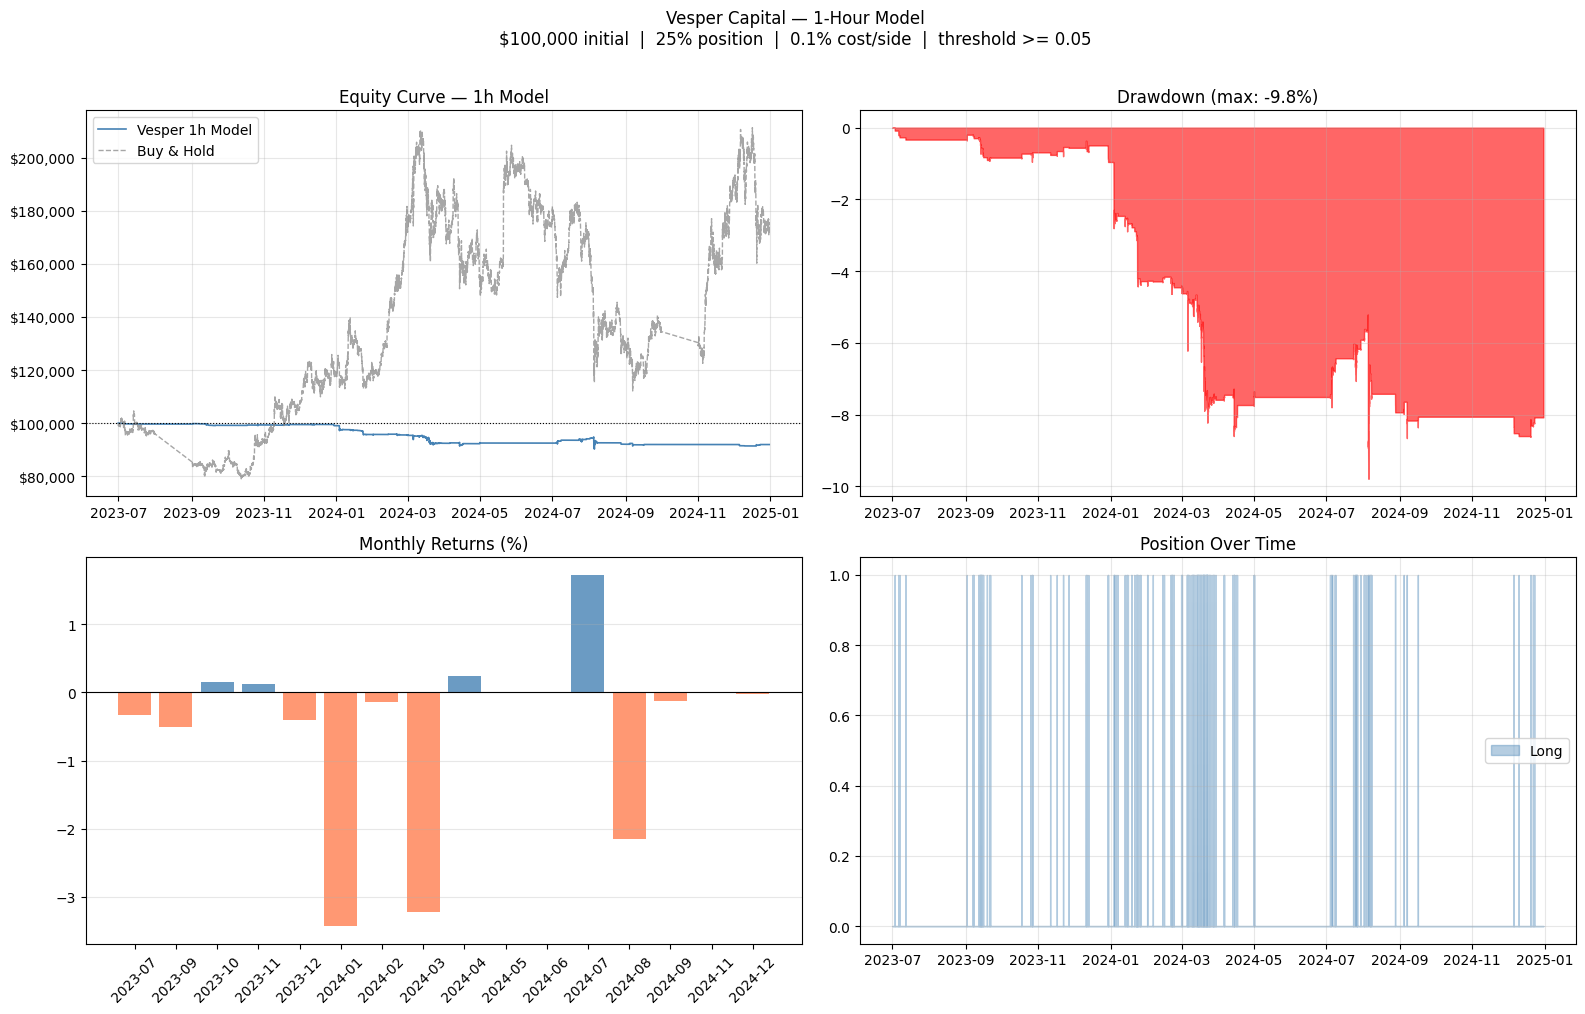

In [8]:
if len(eq_1h) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    ax = axes[0, 0]
    ax.plot(eq_1h['timestamp'], eq_1h['capital'],
            color='steelblue', linewidth=1.2, label='Vesper 1h Model')
    ax.plot(eq_1h['timestamp'], bah_series,
            color='gray', linewidth=1, linestyle='--', alpha=0.7, label='Buy & Hold')
    ax.axhline(INITIAL_CAPITAL, color='black', linewidth=0.8, linestyle=':')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title('Equity Curve — 1h Model'); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[0, 1]
    ax.fill_between(eq_1h['timestamp'], drawdown, 0, alpha=0.6, color='red')
    ax.set_title(f'Drawdown (max: {max_drawdown:.1f}%)'); ax.grid(alpha=0.3)

    ax = axes[1, 0]
    colors = ['steelblue' if r >= 0 else 'coral' for r in monthly['return_pct']]
    ax.bar(monthly['month_period'].astype(str), monthly['return_pct'],
           color=colors, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Monthly Returns (%)')
    ax.tick_params(axis='x', rotation=45); ax.grid(alpha=0.3, axis='y')

    ax = axes[1, 1]
    ax.fill_between(eq_1h['timestamp'],
                    eq_1h['position'], alpha=0.4, color='steelblue', label='Long')
    ax.set_title('Position Over Time'); ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle(
        f'Vesper Capital — 1-Hour Model\n'
        f'${INITIAL_CAPITAL:,.0f} initial  |  {POSITION_PCT*100:.0f}% position  |  '
        f'{TRANSACTION_COST*100:.1f}% cost/side  |  threshold >= {MIN_MEANINGFUL_THRESHOLD}',
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.show()


In [9]:
# Align 1h and 24h model signals by timestamp
# Both models cover the same test months — merge on timestamp

rows_24h = []
for r in long_results:   # 24h model results
    for i in range(len(r['timestamps'])):
        rows_24h.append({
            'timestamp':  pd.Timestamp(r['timestamps'][i]),
            'test_month': r['test_month'],
            'pos_24h':    float(r['positions'][i]),
            'ret_24h':    float(r['actual_returns'][i]),
            'pred_24h':   float(r['y_pred'][i]),
            'threshold_24h': r['threshold'],
        })

rows_1h = []
for r in long_results_1h:   # 1h model results
    for i in range(len(r['timestamps'])):
        rows_1h.append({
            'timestamp': pd.Timestamp(r['timestamps'][i]),
            'pos_1h':    float(r['positions'][i]),
            'pred_1h':   float(r['y_pred'][i]),
            'threshold_1h': r['threshold'],
        })

df_24h = pd.DataFrame(rows_24h)
df_1h  = pd.DataFrame(rows_1h)

# Merge on timestamp
combined = df_24h.merge(df_1h, on='timestamp', how='inner')

# Apply threshold filters
combined['valid_24h'] = combined['threshold_24h'] >= 0.50
combined['valid_1h']  = combined['threshold_1h']  >= 0.05

# Define signal regimes
combined['regime'] = 'flat'
combined.loc[
    combined['valid_24h'] & (combined['pos_24h'] > 0) &
    ~(combined['valid_1h'] & (combined['pos_1h'] > 0)),
    'regime'
] = '24h_only'
combined.loc[
    combined['valid_24h'] & (combined['pos_24h'] > 0) &
    combined['valid_1h']  & (combined['pos_1h']  > 0),
    'regime'
] = 'both'
combined.loc[
    ~(combined['valid_24h'] & (combined['pos_24h'] > 0)) &
    combined['valid_1h']   & (combined['pos_1h']  > 0),
    'regime'
] = '1h_only'

base_mean = combined['ret_24h'].mean()

print("=" * 65)
print("SIGNAL FILTER ANALYSIS")
print("Signal regimes vs 24h forward return")
print("=" * 65)
print(f"Baseline (all hours): {base_mean:+.4f}%")
print()

for regime in ['24h_only', 'both', '1h_only', 'flat']:
    subset = combined[combined['regime'] == regime]
    if len(subset) == 0:
        continue
    mean_ret  = subset['ret_24h'].mean()
    win_rate  = (subset['ret_24h'] > 0).mean()
    edge      = mean_ret - base_mean
    print(f"{regime:<12}: n={len(subset):5d}  "
          f"mean_24h_ret={mean_ret:+.4f}%  "
          f"edge={edge:+.4f}%  "
          f"win_rate={win_rate:.3f}")

print()
print("Key question: does 'both' show materially better edge than '24h_only'?")
both_edge    = combined[combined['regime']=='both']['ret_24h'].mean() - base_mean
only_24h_edge = combined[combined['regime']=='24h_only']['ret_24h'].mean() - base_mean
if len(combined[combined['regime']=='both']) > 10:
    improvement = both_edge - only_24h_edge
    print(f"  24h_only edge:  {only_24h_edge:+.4f}%")
    print(f"  both edge:      {both_edge:+.4f}%")
    print(f"  Improvement:    {improvement:+.4f}%  "
          f"({'✓ filter adds value' if improvement > 0.1 else '✗ filter adds little'})")

NameError: name 'long_results' is not defined